In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import warnings

warnings.simplefilter(action='ignore', category=Warning)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

In [2]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## Define Hypothesis 1
$ 𝐻_{0}:\mu_{1}-\mu_{2} = 0 $ There is no difference between the BMI of male and BMI of female. \
$ 𝐻_{A}:\mu_{1}-\mu_{2} \ne 0 $ There is a difference between the BMI of male and BMI of female.

### Evaluate and interpret the result

In [6]:
female = data[data.sex == 'female']
male = data[data.sex == 'male']

In [7]:
f_bmi = female.bmi
m_bmi = male.bmi

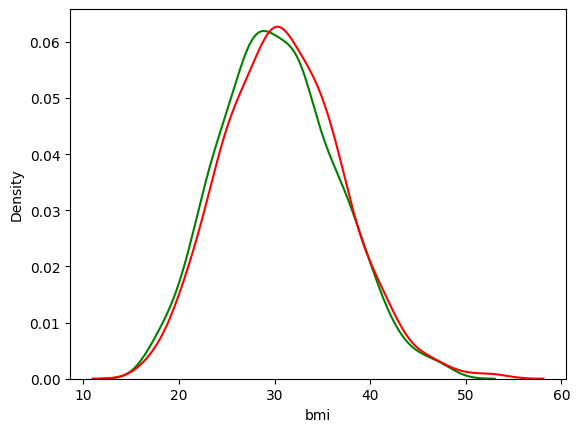

In [10]:
sns.distplot(f_bmi, color='green', hist=False)
sns.distplot(m_bmi, color='red', hist=False);

In [11]:
f_bmi.mean()

30.37774924471299

In [12]:
m_bmi.mean()

30.943128698224854

In [13]:
alpha = 0.5
t_value1, p_value1 = stats.ttest_ind(m_bmi, f_bmi)
print("t_value1: ", t_value1, "p_value1: ", p_value1)

t_value1:  1.696752635752224 p_value1:  0.08997637178984934


In [14]:
if p_value1 < alpha:
    print("Conclusion: since p_value {} is less than alpha {} ". format (p_value1,alpha))
    print("Reject the null hypothesis that there is no difference between bmi of females and bmi of males.")
    
else:
    print("Conclusion: since p_value {} is greater than alpha {} ". format (p_value1,alpha))
    print("Fail to reject the null hypothesis that there is a difference between bmi of females and bmi of males.")

Conclusion: since p_value 0.08997637178984934 is less than alpha 0.5 
Reject the null hypothesis that there is no difference between bmi of females and bmi of males.


## Define Hypothesis 2
$ 𝐻_{0}:\mu_{1} \leq \mu_{2} $ The average charges of smokers are less than or equal to nonsmokers. \
$ 𝐻_{A}:\mu_{1} > \mu_{2} $ The average charges of smokers are greater than or equal to nonsmokers.

In [15]:
smoker_charges = data[data.smoker == 'yes'].charges
smoker_charges.mean()

32050.23183153284

In [16]:
non_smoker_charges = data[data.smoker == 'no'].charges
non_smoker_charges.mean()

8434.268297856204

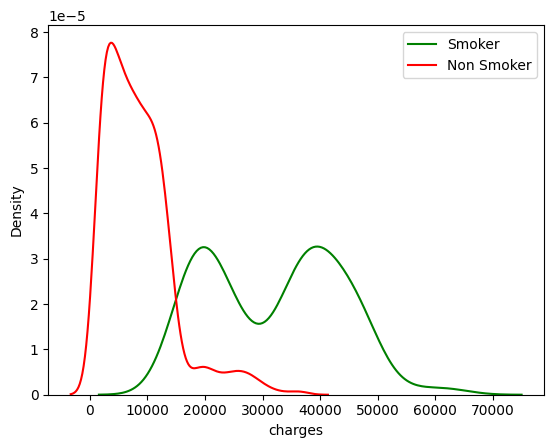

In [24]:
sns.distplot(smoker_charges, color='green', hist=False, label='Smoker')
sns.distplot(non_smoker_charges, color='red', hist=False, label='Non Smoker')
plt.legend();

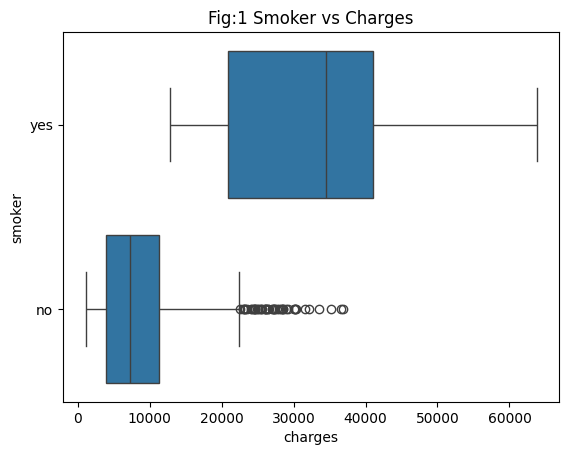

In [25]:
sns.boxplot(x=data.charges, y=data.smoker, data=data).set(title="Fig:1 Smoker vs Charges");

In [17]:
alpha = 0.5
t_value2, p_value2 = stats.ttest_ind(smoker_charges, non_smoker_charges)
print("t_value2: ", t_value2, "p_value2: ", p_value2)

t_value2:  46.66492117272371 p_value2:  8.271435842179102e-283


In [19]:
if p_value2 < alpha:
    print("Conclusion: since p_value {} is less than alpha {} ". format (p_value1,alpha))
    print("Reject the null hypothesis that there is no difference between bmi of females and bmi of males.")
    
else:
    print("Conclusion: since p_value {} is greater than alpha {} ". format (p_value1,alpha))
    print("Fail to reject the null hypothesis that there is a difference between bmi of females and bmi of males.")

Conclusion: since p_value 0.08997637178984934 is less than alpha 0.5 
Reject the null hypothesis that there is no difference between bmi of females and bmi of males.


### Define Hypothesis 3
$ 𝐻_{0}:\mu_{1}=\mu_{2}=\mu_{3} $ The mean BMI of women with no children , one child, and two children are the same. \
$ 𝐻_{A}: $ At least one of the means for women's BMI is not the same.


In [31]:
female_children = data[data.children <= 2]
female_children.groupby(['children'])['bmi'].mean()

children
0    30.550296
1    30.623148
2    30.978104
Name: bmi, dtype: float64

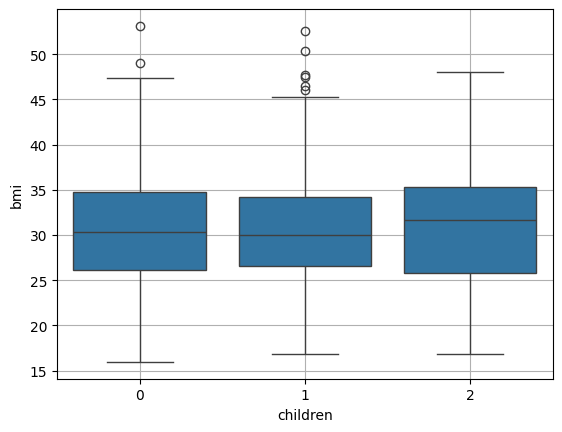

In [32]:
sns.boxplot(x='children', y='bmi', data=female_children)
plt.grid()
plt.show()

In [33]:
forrmula = 'bmi ~ C(children)'
model = ols(forrmula, female_children).fit()
aov_table = anova_lm(model)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
C(children),2.0,31.631915,15.815957,0.416983,0.659133
Residual,1135.0,43049.991501,37.929508,NaN,NaN


Since p-value is 0.659133 and greater then alpha (0.5) we fail the reject null hypothesis. And conclude that the mean bmi of women with no children, one child, and two children are the same.

### Define Hypothesis 4
$ 𝐻_{0} $: Smokers proportions are not significantly different across the different regions. \
$ 𝐻_{A} $: Smokers proportions are different across the different regions.

In [34]:
contingency = pd.crosstab(data.region, data.smoker)
contingency

smoker,no,yes
region,,
northeast,257,67
northwest,267,58
southeast,273,91
southwest,267,58


<Axes: xlabel='region'>

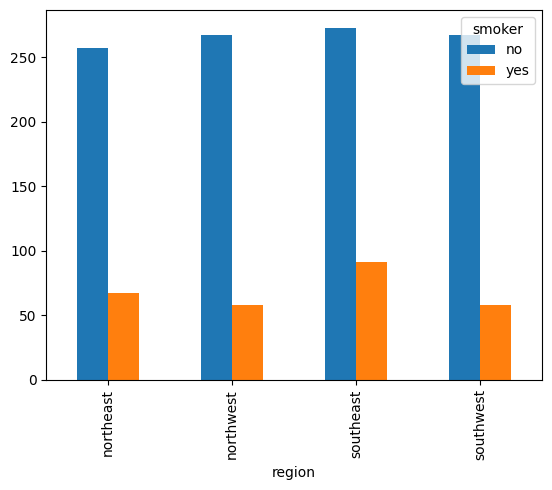

In [35]:
contingency.plot(kind='bar')

In [37]:
chi2, p_val,dof, exp_freq = chi2_contingency(contingency, correction=False)
print('chi-square statistic: {} , p_value: {} , degree of freedom: {} ,expected frequencies: {} '.format(chi2, p_val, dof, exp_freq))

chi-square statistic: 7.343477761407071 , p_value: 0.06171954839170541 , degree of freedom: 3 ,expected frequencies: [[257.65022422  66.34977578]
 [258.44544096  66.55455904]
 [289.45889387  74.54110613]
 [258.44544096  66.55455904]] 


In [38]:
# Enter your code and run the cell
if p_val < alpha:
    print("Conclusion: since p_value {} is less than alpha {} ". format (p_val,alpha))
    print("Reject the null hypothesis that smokers proportions are not significantly different across the different regions.")
    
else:
    print("Conclusion: since p_value {} is greater than alpha {} ". format (p_val,alpha))
    print("Fail to reject the null hypothesis that smokers proportions are different across the different regions.")

Conclusion: since p_value 0.06171954839170541 is less than alpha 0.5 
Reject the null hypothesis that smokers proportions are not significantly different across the different regions.
